# Data Analysis Toolbox Session 2
### Author: Gururaj Deshpande

## Real Example
#### Let's create an 8-bit grayscale bit-depth, 512 x 512 derived image for easy use in demos

#### [What is Kernel](http://setosa.io/ev/image-kernels/)

In [48]:
import numpy as np
from scipy.datasets import ascent
import matplotlib.pyplot as plt
img = ascent()

In [49]:
img.shape

(512, 512)

In [50]:
img.max()

np.uint8(255)

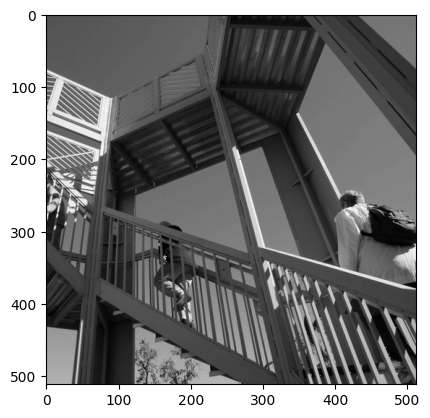

In [51]:
plt.gray()
plt.imshow(img)
plt.show()

**Blur the image: for each pixel, replace the value to the average of its eight neighbors and itself**

In [52]:
F = np.ones((3, 3),np.float32) / 9
F

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]], dtype=float32)

In [53]:
m, n = img.shape
blurred = np.zeros((m, n))

In [54]:
for i in range(1, m-1):
    for j in range(1, n-1):
        blurred[i][j] = np.sum(img[i-1:i+2, j-1:j+2] * F)
blurred

array([[  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  82.22222137,  82.66666412, ..., 117.        ,
        117.        ,   0.        ],
       [  0.        ,  82.        ,  82.55555725, ..., 117.        ,
        117.        ,   0.        ],
       ...,
       [  0.        , 177.66665649, 177.66665649, ...,  56.66666794,
         58.22222137,   0.        ],
       [  0.        , 178.        , 178.        , ...,  54.        ,
         57.22222137,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

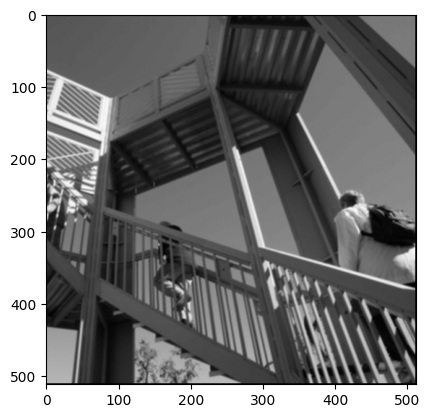

In [55]:
plt.imshow(blurred)
plt.show()

# Matplotlib

#### Scatter Plot

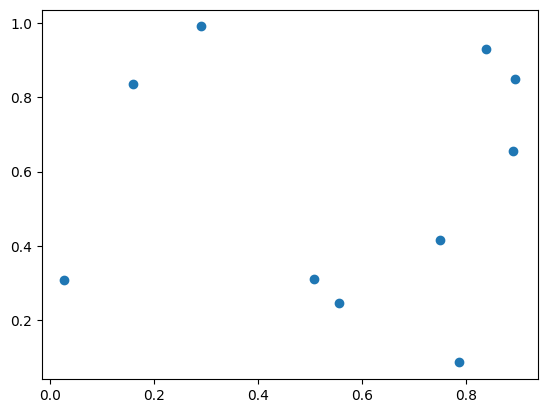

In [56]:
import numpy.random as nprd
x = nprd.random(10)
y = nprd.random(10)
plt.scatter(x, y)

#### Histogram

In [57]:
x = [1, 2, 2, 2, 3, 2, 1, 3, 2, 2, 4]

(array([2., 6., 2., 1.]),
 array([1.  , 1.75, 2.5 , 3.25, 4.  ]),
 <BarContainer object of 4 artists>)

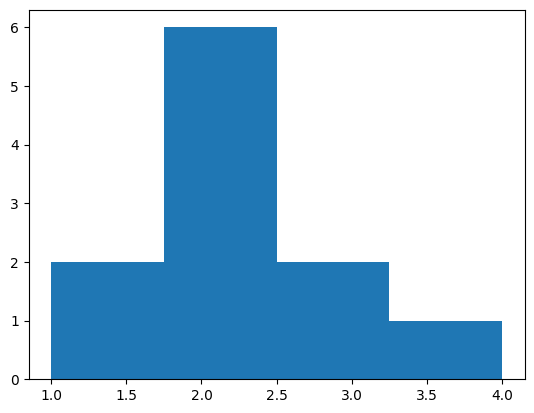

In [58]:
plt.hist(x, bins=4)

#### Lines

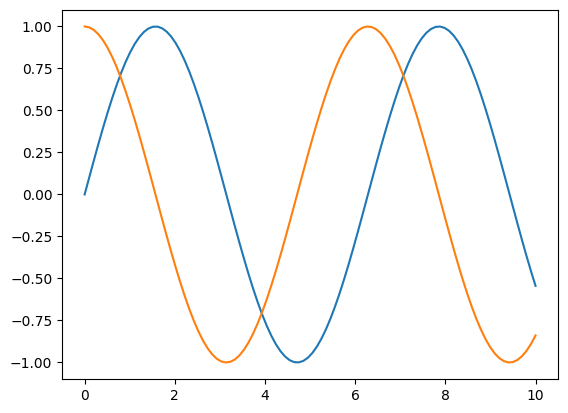

In [59]:
x = np.linspace(0, 10, 100)

plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))

plt.show()

#### Linepoints

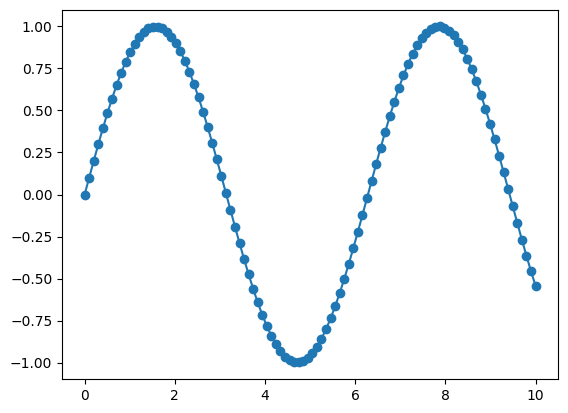

In [60]:
plt.plot(x, np.sin(x), 'o-')
plt.show()

#### Bars

array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
        5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ])

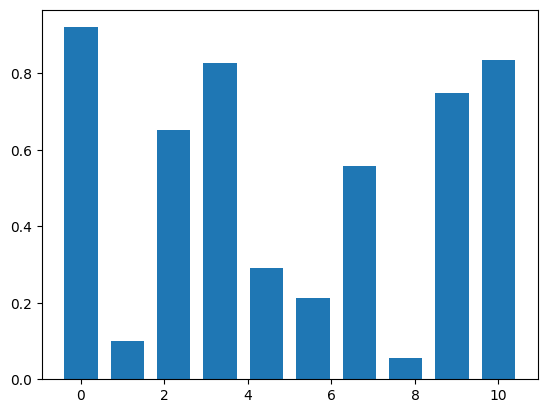

In [61]:
x = np.linspace(0, 10, 10)
y = nprd.random(10)
plt.bar(x, y)
x

# Probability Distributions

## Generate random samples

#### [Uniform Distribution](https://en.wikipedia.org/wiki/Discrete_uniform_distribution)

In [62]:
x = nprd.uniform(0, 1, 10000)
x.shape

(10000,)

(array([ 994., 1042.,  965.,  977.,  987., 1013., 1039., 1023.,  985.,
         975.]),
 array([1.30290835e-04, 1.00116413e-01, 2.00102536e-01, 3.00088658e-01,
        4.00074781e-01, 5.00060904e-01, 6.00047026e-01, 7.00033149e-01,
        8.00019271e-01, 9.00005394e-01, 9.99991516e-01]),
 <BarContainer object of 10 artists>)

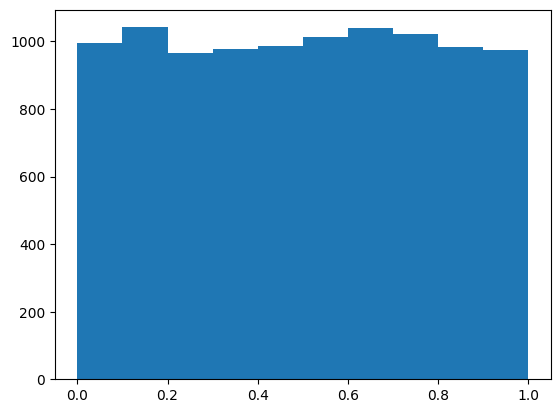

In [63]:
plt.hist(x, 10)

#### [Binomial Distribution](https://en.wikipedia.org/wiki/Binomial_distribution)

In [64]:
x = nprd.binomial(10, 0.7, 1000)

(array([  3.,   0.,  13.,   0.,   0.,  42.,   0.,  91.,   0.,   0., 190.,
          0., 271.,   0.,   0., 240.,   0., 125.,   0.,  25.]),
 array([ 2. ,  2.4,  2.8,  3.2,  3.6,  4. ,  4.4,  4.8,  5.2,  5.6,  6. ,
         6.4,  6.8,  7.2,  7.6,  8. ,  8.4,  8.8,  9.2,  9.6, 10. ]),
 <BarContainer object of 20 artists>)

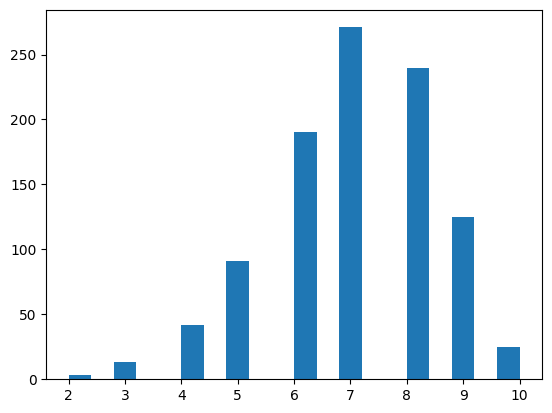

In [65]:
plt.hist(x, 20)

#### [Gaussian Distribution](https://en.wikipedia.org/wiki/Normal_distribution)

In [66]:
x = nprd.normal(0, 1.0, 1000)

#### [68–95–99.7 Rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule)

(array([ 12.,  26.,  84., 172., 256., 248., 122.,  61.,  11.,   8.]),
 array([-3.01632284, -2.37957488, -1.74282693, -1.10607897, -0.46933101,
         0.16741695,  0.80416491,  1.44091286,  2.07766082,  2.71440878,
         3.35115674]),
 <BarContainer object of 10 artists>)

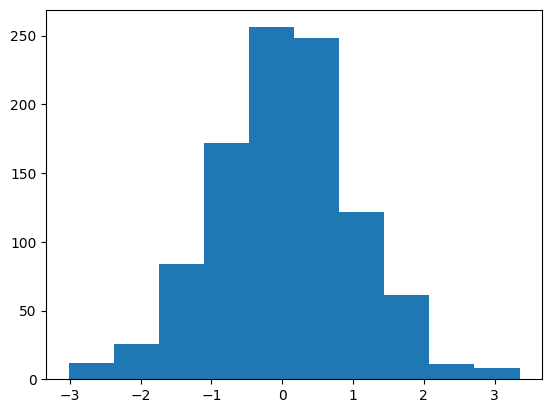

In [67]:
plt.hist(x)

#### 2D Gaussian
$$ Covariance = \left( \begin{array}{ccc}  \sigma(x, x) & \sigma(x, y) \\  \sigma(y, x) & \sigma(y, y) \end{array} \right)$$

In [68]:
mean = [0, 0]
cov = [[1, -20], [-20, 625]]
x, y = nprd.multivariate_normal(mean, cov, 1000).T


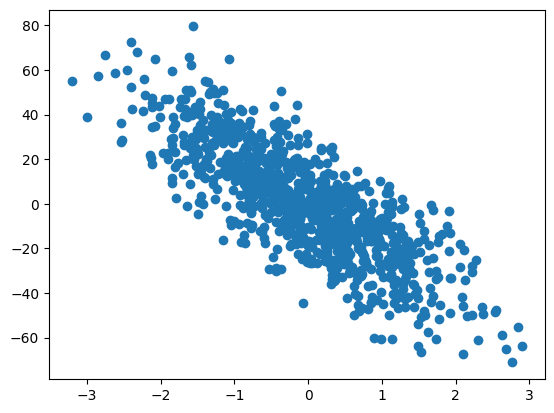

In [69]:
plt.scatter(x, y)

## Estimate Parameters from Samples

---



In [70]:
x = nprd.normal(0, 1.0, 1000)

In [71]:
mu = np.mean(x)
sigma = np.std(x)
mu, sigma

(np.float64(-0.001552782359356776), np.float64(1.0165670631079318))

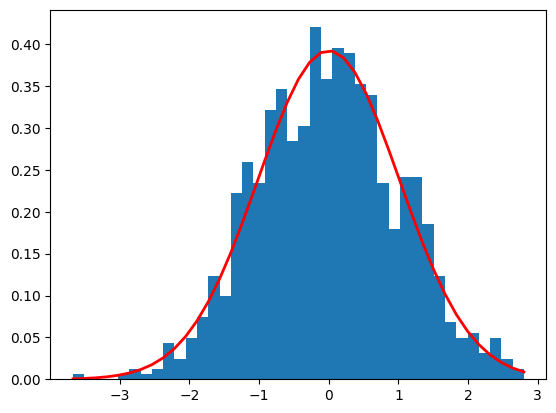

In [72]:
count, bins, ignored = plt.hist(x, 40, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) ),  linewidth=2, color='r')
plt.show()

In [73]:
bins

array([-3.67048678, -3.5087054 , -3.34692403, -3.18514266, -3.02336129,
       -2.86157991, -2.69979854, -2.53801717, -2.37623579, -2.21445442,
       -2.05267305, -1.89089168, -1.7291103 , -1.56732893, -1.40554756,
       -1.24376618, -1.08198481, -0.92020344, -0.75842207, -0.59664069,
       -0.43485932, -0.27307795, -0.11129658,  0.0504848 ,  0.21226617,
        0.37404754,  0.53582892,  0.69761029,  0.85939166,  1.02117303,
        1.18295441,  1.34473578,  1.50651715,  1.66829853,  1.8300799 ,
        1.99186127,  2.15364264,  2.31542402,  2.47720539,  2.63898676,
        2.80076813])